In [ ]:
# 🎙️ Deepfake Voice Detection – LA Dataset (Baseline)

This notebook implements a deepfake voice detection system using a Light Convolutional Neural Network (LCNN) on the ASVspoof2019 Logical Access (LA) dataset.

The goal is to classify audio samples as:
- **Bonafide (real)**
- **Spoof (fake)**

This serves as a baseline experiment under controlled (clean) conditions.

In [ ]:
## 📦 1. Import Libraries

We import the necessary libraries for:
- Audio processing (Librosa)
- Deep learning (PyTorch)
- Data handling (NumPy)
- Visualization (Matplotlib)

In [ ]:
import os
import zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_curve, confusion_matrix
from google.colab import drive


In [ ]:
drive.mount("/content/drive")

zip_path = "/content/drive/MyDrive/LA.zip"
extract_root = "/content/asvspoof2019_LA"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_root)

print("Dataset extracted.")


Mounted at /content/drive
Dataset extracted.


In [ ]:
import random, numpy as np, torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [ ]:
## 📂 2. Dataset Preparation

The ASVspoof2019 LA dataset contains synthetic speech generated using:
- Text-to-Speech (TTS)
- Voice Conversion (VC)

Each audio file is labeled as:
- **1 → Bonafide (real)**
- **0 → Spoof (fake)**

Protocol files are used to map audio files to their labels.

In [ ]:
extract_path = "/content/asvspoof2019_LA/LA"

train_flac_path = os.path.join(extract_path, "ASVspoof2019_LA_train", "flac")
dev_flac_path   = os.path.join(extract_path, "ASVspoof2019_LA_dev", "flac")

proto_dir = os.path.join(extract_path, "ASVspoof2019_LA_cm_protocols")

def load_protocol(protocol_path):
    labels = {}
    with open(protocol_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            file_id = parts[1]
            label = parts[-1]
            labels[file_id] = label
    return labels

train_protocol = os.path.join(proto_dir, "ASVspoof2019.LA.cm.train.trn.txt")
dev_protocol   = os.path.join(proto_dir, "ASVspoof2019.LA.cm.dev.trl.txt")

train_labels = load_protocol(train_protocol)
dev_labels   = load_protocol(dev_protocol)

print("Train samples:", len(train_labels))
print("Dev samples:", len(dev_labels))


Train samples: 25380
Dev samples: 24844


In [ ]:
from collections import Counter

label_counts = Counter(train_labels.values())

print("Train class distribution:", label_counts)

total = sum(label_counts.values())

weight_bonafide = total / label_counts['bonafide']
weight_spoof = total / label_counts['spoof']

print("Weight bonafide:", weight_bonafide)
print("Weight spoof:", weight_spoof)

Train class distribution: Counter({'spoof': 22800, 'bonafide': 2580})
Weight bonafide: 9.837209302325581
Weight spoof: 1.1131578947368421


In [ ]:
# Label mapping
label_map = {
    "bonafide": 0,
    "spoof": 1
}


In [ ]:
## 🔊 3. Feature Extraction (Log-Mel Spectrogram)

Audio signals are converted into log-Mel spectrograms to capture time-frequency characteristics.

Configuration:
- Sampling rate: 16 kHz
- Mel bands: 80
- FFT size: 1024
- Hop length: 256

The output is resized to a fixed shape for model input.

In [ ]:
import os
import torch
import numpy as np
import librosa
from torch.utils.data import Dataset

label_map = {"bonafide": 0, "spoof": 1}

class ASVspoofDataset(Dataset):
    def __init__(self, flac_path, labels_dict, noise_level=0.0):
        self.flac_path = flac_path
        self.labels_dict = labels_dict
        self.noise_level = noise_level

        self.files = []
        for f in os.listdir(flac_path):
            file_id = f.replace(".flac", "")
            if file_id in labels_dict:
                self.files.append(f)

        print("Usable files:", len(self.files))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        filename = self.files[idx]
        file_id = filename.replace(".flac", "")

        audio_path = os.path.join(self.flac_path, filename)
        audio, sr = librosa.load(audio_path, sr=16000)

        # Optional noise
        if self.noise_level > 0:
            noise = np.random.randn(len(audio))
            audio = audio + self.noise_level * noise

        # Log-Mel only
        mel = librosa.feature.melspectrogram(
            y=audio,
            sr=sr,
            n_mels=80
        )
        logmel = librosa.power_to_db(mel)

        # Fix size (1, 80, 300)
        max_len = 300
        logmel = logmel[:, :max_len]

        if logmel.shape[1] < max_len:
            pad_width = max_len - logmel.shape[1]
            logmel = np.pad(
                logmel,
                ((0, 0), (0, pad_width)),
                mode='constant'
            )

        x = torch.tensor(logmel).unsqueeze(0).float()
        y = label_map[self.labels_dict[file_id]]

        return x, y

In [ ]:
## 🧠 4. Model Architecture (LCNN)

We use a Light Convolutional Neural Network (LCNN) with:

- Convolutional layers for feature extraction
- Max-Feature-Map (MFM) activation
- Fully connected layers for classification

MFM helps select important features and reduces model complexity.

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class MFM(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels * 2, kernel_size=3, padding=1)

    def forward(self, x):
        x = self.conv(x)
        out, gate = torch.chunk(x, 2, dim=1)
        return torch.max(out, gate)


class LCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Block 1
        self.layer1 = MFM(1, 16)
        self.bn1 = nn.BatchNorm2d(16)
        self.pool1 = nn.MaxPool2d(2, 2)

        # Block 2
        self.layer2 = MFM(16, 32)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool2 = nn.MaxPool2d(2, 2)

        # Block 3
        self.layer3 = MFM(32, 64)
        self.bn3 = nn.BatchNorm2d(64)
        self.pool3 = nn.MaxPool2d(2, 2)

        # Fully connected
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64 * 10 * 37, 128)
        self.fc2 = nn.Linear(128, 2)

    def forward(self, x):
        x = self.pool1(self.bn1(self.layer1(x)))
        x = self.pool2(self.bn2(self.layer2(x)))
        x = self.pool3(self.bn3(self.layer3(x)))

        x = x.view(x.size(0), -1)

        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)

        return x

In [ ]:
from collections import Counter

counts = Counter(train_labels.values())
print(counts)

Counter({'spoof': 22800, 'bonafide': 2580})


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LCNN().to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
w_bonafide = 1.0
w_spoof = counts["bonafide"] / counts["spoof"]

weights = torch.tensor([w_bonafide, w_spoof]).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

def train_one_epoch(model, loader):
    model.train()
    for batch_idx, (x,y) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        if batch_idx % 50 == 0:
            print(f"Batch {batch_idx}, Loss: {loss.item():.4f}")


In [ ]:
def compute_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1)
            correct += (preds==y).sum().item()
            total += y.size(0)
    return correct/total

def compute_eer(model, loader):
    model.eval()
    scores = []
    labels = []

    with torch.no_grad():
        for x,y in loader:
            x = x.to(device)
            outputs = model(x)
            probs = torch.softmax(outputs, dim=1)[:,1]
            scores.extend(probs.cpu().numpy())
            labels.extend(y.cpu().numpy())

    fpr, tpr, _ = roc_curve(labels, scores)
    fnr = 1 - tpr
    eer = fpr[np.nanargmin(np.abs(fnr - fpr))]
    return eer * 100


In [ ]:
def plot_confusion(model, loader):
    model.eval()
    preds = []
    labels = []

    with torch.no_grad():
        for x,y in loader:
            x = x.to(device)
            outputs = model(x)
            p = torch.argmax(outputs, dim=1)
            preds.extend(p.cpu().numpy())
            labels.extend(y.numpy())

    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()


In [ ]:
def plot_roc(model, loader):
    model.eval()
    scores = []
    labels = []

    with torch.no_grad():
        for x,y in loader:
            x = x.to(device)
            outputs = model(x)
            probs = torch.softmax(outputs, dim=1)[:,1]
            scores.extend(probs.cpu().numpy())
            labels.extend(y.numpy())

    fpr, tpr, _ = roc_curve(labels, scores)
    plt.plot(fpr, tpr)
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title("ROC Curve")
    plt.show()


In [ ]:
def noise_sweep(model, noise_levels):
    results = {}
    for level in noise_levels:
        noisy_dataset = ASVspoofDataset(dev_flac_path, dev_labels, noise_level=level)
        noisy_loader = DataLoader(noisy_dataset, batch_size=32, shuffle=False)
        eer = compute_eer(model, noisy_loader)
        results[level] = eer
    return results


In [ ]:
train_dataset = ASVspoofDataset(train_flac_path, train_labels, noise_level=0.0)
dev_dataset   = ASVspoofDataset(dev_flac_path, dev_labels, noise_level=0.0)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
dev_loader   = DataLoader(dev_dataset, batch_size=16, shuffle=False)

Usable files: 25380
Usable files: 24844


In [ ]:
def compute_dev_loss(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for batch_idx, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 200 == 0:
            print(f"Batch {batch_idx}, Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    return avg_loss

In [ ]:
## ⚙️ 5. Training

The model is trained using:

- Optimizer: Adam
- Learning rate: 1e-4
- Loss function: CrossEntropyLoss

The model learns to distinguish between real and spoofed speech.

In [ ]:
best_dev_loss = float("inf")
best_model_path = "best_lcnn_model.pth"

train_losses = []
dev_losses = []
eers = []

num_epochs = 5

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train_loss = train_one_epoch(model, train_loader)
    dev_loss = compute_dev_loss(model, dev_loader)
    eer = compute_eer(model, dev_loader)

    train_losses.append(train_loss)
    dev_losses.append(dev_loss)
    eers.append(eer)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Dev Loss: {dev_loss:.4f}")
    print(f"Dev EER: {eer:.4f}")


    if dev_loss < best_dev_loss:
        best_dev_loss = dev_loss
        torch.save(model.state_dict(), best_model_path)
        print("Best model saved!")


Epoch 1/5
Batch 0, Loss: 0.6582
Batch 200, Loss: 0.6217
Batch 400, Loss: 0.0634
Batch 600, Loss: 1.0598
Batch 800, Loss: 0.0347
Batch 1000, Loss: 0.0067
Batch 1200, Loss: 0.0231
Batch 1400, Loss: 0.0252
Train Loss: 0.2121
Dev Loss: 0.0924
Dev EER: 2.9827
Best model saved!

Epoch 2/5
Batch 0, Loss: 0.0295
Batch 200, Loss: 0.0242
Batch 400, Loss: 0.1170
Batch 600, Loss: 0.0085
Batch 800, Loss: 0.0207
Batch 1000, Loss: 0.0023
Batch 1200, Loss: 0.0154
Batch 1400, Loss: 0.0131
Train Loss: 0.0503
Dev Loss: 0.1009
Dev EER: 2.3940

Epoch 3/5
Batch 0, Loss: 0.0017
Batch 200, Loss: 0.0075
Batch 400, Loss: 0.0002
Batch 600, Loss: 0.0006
Batch 800, Loss: 0.0026
Batch 1000, Loss: 0.0190
Batch 1200, Loss: 0.0059
Batch 1400, Loss: 0.0215
Train Loss: 0.0328
Dev Loss: 0.0956
Dev EER: 2.4725

Epoch 4/5
Batch 0, Loss: 0.0080
Batch 200, Loss: 0.0010
Batch 400, Loss: 0.0012
Batch 600, Loss: 0.0026
Batch 800, Loss: 0.0006
Batch 1000, Loss: 0.0007
Batch 1200, Loss: 0.0002
Batch 1400, Loss: 0.0001
Train Loss

In [ ]:
model.load_state_dict(torch.load(best_model_path))
print("Best model loaded.")

Best model loaded.


In [ ]:
torch.save(model.state_dict(), "final_lcnn_stable.pth")

In [ ]:
## 📊 6. Evaluation

The model is evaluated using:

- Accuracy
- Equal Error Rate (EER)

EER is the main metric, representing the point where:
- False Acceptance Rate = False Rejection Rate

In [ ]:
final_acc = compute_accuracy(model, dev_loader)
final_eer = compute_eer(model, dev_loader)

print("Final Dev Accuracy:", final_acc)
print("Final Dev EER (%):", final_eer)

Final Dev Accuracy: 0.9927547898889068
Final Dev EER (%): 1.4128728414442702


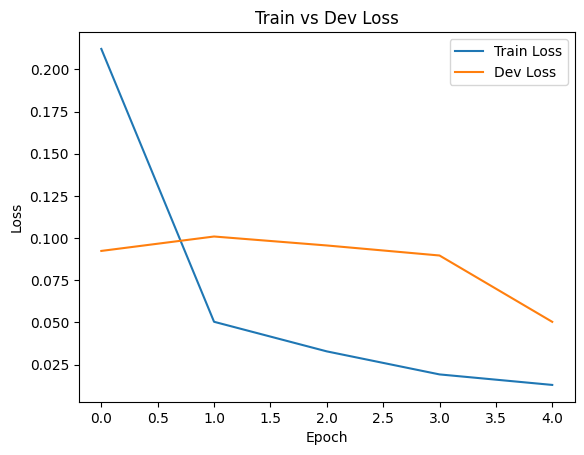

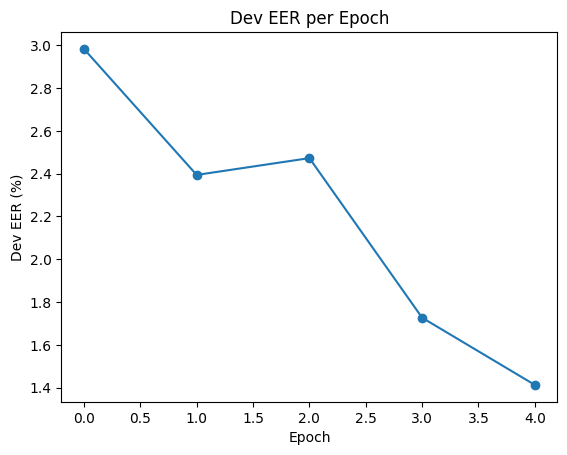

In [ ]:
import matplotlib.pyplot as plt

# Loss graph
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(dev_losses, label="Dev Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Train vs Dev Loss")
plt.show()

# EER graph
plt.figure()
plt.plot(eers, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Dev EER (%)")
plt.title("Dev EER per Epoch")
plt.show()

In [ ]:
levels = [0.0, 0.02, 0.05]
results = noise_sweep(model, levels)

print(results)

Usable files: 24844
Usable files: 24844
Usable files: 24844
{0.0: np.float64(1.4128728414442702), 0.02: np.float64(26.138147566718995), 0.05: np.float64(33.63422291993721)}


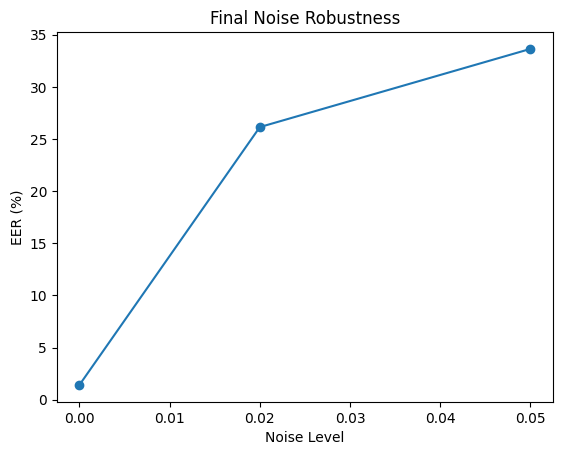

In [ ]:
plt.figure()
plt.plot(list(results.keys()), list(results.values()), marker='o')
plt.xlabel("Noise Level")
plt.ylabel("EER (%)")
plt.title("Final Noise Robustness")
plt.show()

In [ ]:
def compute_dev_loss(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            loss = criterion(outputs, y)
            total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def noise_sweep(model, noise_levels):
    results = {}

    for level in noise_levels:
        print(f"Testing noise level: {level}")

        noisy_dataset = ASVspoofDataset(
            dev_flac_path,
            dev_labels,
            noise_mode=None if level == 0.0 else "fixed"
        )


        if level != 0.0:
            noisy_dataset.noise_mode = "random"

        noisy_loader = DataLoader(noisy_dataset, batch_size=16, shuffle=False)

        eer = compute_eer(model, noisy_loader)
        results[level] = eer

    return results


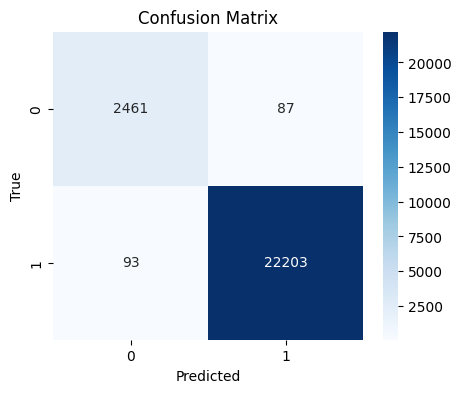

In [ ]:
plot_confusion(model, dev_loader)


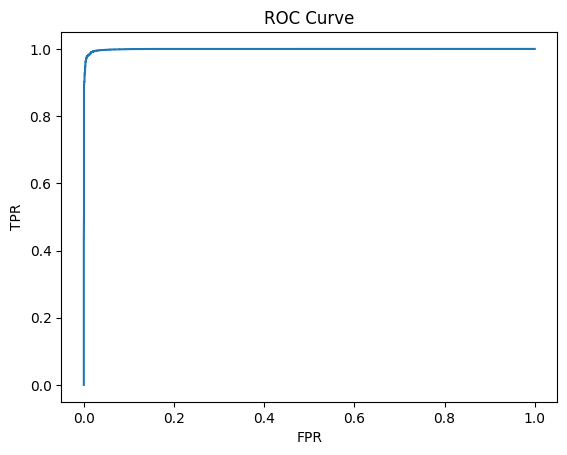

In [ ]:
plot_roc(model, dev_loader)


In [ ]:
## 📈 7. Results

- Accuracy: **99.27%**
- EER: **1.41%**

The model achieves excellent performance on the LA dataset due to the controlled and clean nature of synthetic speech data.

The ROC curve shows near-perfect classification performance.

In [ ]:
## 🧾 8. Conclusion

This baseline model demonstrates that LCNN with log-Mel spectrograms is highly effective for detecting synthetic speech in controlled environments.

However, this performance may not generalize well to real-world conditions, which will be explored in later experiments.